
# Annual Promo vs Non-promo Stacked Bar

Notebook này tạo biểu đồ **100% stacked bar theo năm** để so sánh:

1. Promo vs non-promo **line share**
2. Promo vs non-promo **quantity share**
3. Xuất bảng số liệu `annual_promo_share.csv`
4. Xuất bảng kinh tế `annual_promo_economics.csv`

Cách tính dùng **weighted yearly share**:

/[
\text{Promo line share}_y =
/frac{/text{Total promo lines in year } y}{\text{Total order-item lines in year } y}
\]

Tức là aggregate toàn bộ line trong năm rồi mới chia, không lấy trung bình đơn giản của 12 tháng.


## 1. Import thư viện và cấu hình đường dẫn

In [12]:
from pathlib import Path
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Global plot font settings
# Chỉnh các giá trị này để đổi font size toàn bộ EDA 1.
# Figsize giữ nguyên, chỉ tăng/giảm chữ.
# ============================================================
TITLE_SIZE = 16
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 11
ANNOT_SIZE = 11

def style_axis_fonts(ax):
    """Apply readable font sizes to title, axis labels and tick labels."""
    ax.title.set_fontsize(TITLE_SIZE)
    ax.xaxis.label.set_fontsize(LABEL_SIZE)
    ax.yaxis.label.set_fontsize(LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

DATA_DIR = Path("C:/Users/Admin/Downloads/Vin Datathon/data")
OUT_DIR = Path("C:/Users/Admin/Downloads/Vin Datathon/EDA")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())


DATA_DIR: C:\Users\Admin\Downloads\Vin Datathon\data
OUT_DIR: C:\Users\Admin\Downloads\Vin Datathon\EDA


### Font size controls

Các hình trong notebook dùng chung các biến `TITLE_SIZE`, `LABEL_SIZE`, `TICK_SIZE`, `LEGEND_SIZE`, `ANNOT_SIZE` ở cell cấu hình.  
Muốn chữ lớn/nhỏ hơn, chỉ cần đổi các giá trị này và chạy lại các cell vẽ hình; kích thước figure (`figsize`) không đổi.

## 2. Load dữ liệu

In [2]:
orders_path = DATA_DIR / "orders.csv"
items_path = DATA_DIR / "order_items.csv"
products_path = DATA_DIR / "products.csv"

for path in [orders_path, items_path, products_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

orders = pd.read_csv(orders_path, parse_dates=["order_date"])
order_items = pd.read_csv(items_path, low_memory=False)
products = pd.read_csv(products_path)

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)


orders: (646945, 8)
order_items: (714669, 7)
products: (2412, 8)


## 3. Gom bảng và tạo biến promo

In [3]:

df = (
    order_items
    .merge(orders[["order_id", "order_date"]], on="order_id", how="left")
    .merge(products[["product_id", "category", "cogs"]], on="product_id", how="left")
)

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df = df[df["order_date"].notna()].copy()
df["year"] = df["order_date"].dt.year

for col in ["quantity", "unit_price", "discount_amount", "cogs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

# Một dòng được xem là promo nếu có promo_id hoặc promo_id_2.
df["promo_flag"] = (
    df["promo_id"].notna() | df["promo_id_2"].notna()
).astype(int)

df["line_count"] = 1
df["promo_lines"] = df["promo_flag"]
df["nonpromo_lines"] = 1 - df["promo_flag"]

df["promo_quantity"] = df["quantity"] * df["promo_flag"]
df["nonpromo_quantity"] = df["quantity"] * (1 - df["promo_flag"])

df["net_revenue"] = df["quantity"] * df["unit_price"]
df["gross_sales_before_discount"] = df["net_revenue"] + df["discount_amount"]
df["gross_profit"] = df["net_revenue"] - df["quantity"] * df["cogs"]

df["promo_net_revenue"] = df["net_revenue"] * df["promo_flag"]
df["nonpromo_net_revenue"] = df["net_revenue"] * (1 - df["promo_flag"])
df["promo_gross_profit"] = df["gross_profit"] * df["promo_flag"]
df["nonpromo_gross_profit"] = df["gross_profit"] * (1 - df["promo_flag"])

df.head()


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,category,cogs,...,nonpromo_lines,promo_quantity,nonpromo_quantity,net_revenue,gross_sales_before_discount,gross_profit,promo_net_revenue,nonpromo_net_revenue,promo_gross_profit,nonpromo_gross_profit
0,1,2400,7,1138.22,0.0,NaN,NaN,2012-07-04,GenZ,1053.798008,...,1,0,7,7967.54,7967.54,590.953944,0.00,7967.54,0.000000,590.953944
1,2,609,7,10166.25,0.0,NaN,,2012-07-04,Streetwear,8987.704231,...,0,7,0,71163.75,71163.75,8249.820383,71163.75,0.00,8249.820383,0.000000
2,3,396,3,11220.33,0.0,NaN,NaN,2012-07-04,Streetwear,10091.012260,...,1,0,3,33660.99,33660.99,3387.953220,0.00,33660.99,0.000000,3387.953220
3,4,635,5,10639.25,0.0,NaN,NaN,2012-07-04,Streetwear,9205.430478,...,1,0,5,53196.25,53196.25,7169.097610,0.00,53196.25,0.000000,7169.097610
4,6,1935,1,1597.84,0.0,NaN,NaN,2012-07-06,Outdoor,1048.696357,...,1,0,1,1597.84,1597.84,549.143643,0.00,1597.84,0.000000,549.143643


## 4. Tạo bảng annual share và economics

In [4]:

annual = (
    df.groupby("year", as_index=False)
    .agg(
        total_lines=("line_count", "sum"),
        promo_lines=("promo_lines", "sum"),
        nonpromo_lines=("nonpromo_lines", "sum"),
        total_quantity=("quantity", "sum"),
        promo_quantity=("promo_quantity", "sum"),
        nonpromo_quantity=("nonpromo_quantity", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        promo_net_revenue=("promo_net_revenue", "sum"),
        nonpromo_net_revenue=("nonpromo_net_revenue", "sum"),
        total_gross_profit=("gross_profit", "sum"),
        promo_gross_profit=("promo_gross_profit", "sum"),
        nonpromo_gross_profit=("nonpromo_gross_profit", "sum"),
        total_discount=("discount_amount", "sum"),
    )
)

# Weighted annual share: aggregate trước, chia sau.
annual["promo_line_share"] = annual["promo_lines"] / annual["total_lines"].replace(0, np.nan)
annual["nonpromo_line_share"] = annual["nonpromo_lines"] / annual["total_lines"].replace(0, np.nan)

annual["promo_quantity_share"] = annual["promo_quantity"] / annual["total_quantity"].replace(0, np.nan)
annual["nonpromo_quantity_share"] = annual["nonpromo_quantity"] / annual["total_quantity"].replace(0, np.nan)

annual["promo_net_revenue_share"] = annual["promo_net_revenue"] / annual["total_net_revenue"].replace(0, np.nan)
annual["nonpromo_net_revenue_share"] = annual["nonpromo_net_revenue"] / annual["total_net_revenue"].replace(0, np.nan)

annual["total_gross_margin"] = annual["total_gross_profit"] / annual["total_net_revenue"].replace(0, np.nan)
annual["promo_gross_margin"] = annual["promo_gross_profit"] / annual["promo_net_revenue"].replace(0, np.nan)
annual["nonpromo_gross_margin"] = annual["nonpromo_gross_profit"] / annual["nonpromo_net_revenue"].replace(0, np.nan)
annual["discount_to_revenue"] = annual["total_discount"] / annual["total_net_revenue"].replace(0, np.nan)

annual_share = annual[
    [
        "year",
        "promo_line_share",
        "nonpromo_line_share",
        "promo_quantity_share",
        "nonpromo_quantity_share",
        "promo_net_revenue_share",
        "nonpromo_net_revenue_share",
    ]
].copy()

annual_econ = annual[
    [
        "year",
        "total_lines",
        "promo_lines",
        "nonpromo_lines",
        "total_quantity",
        "promo_quantity",
        "nonpromo_quantity",
        "total_net_revenue",
        "promo_net_revenue",
        "nonpromo_net_revenue",
        "total_gross_profit",
        "promo_gross_profit",
        "nonpromo_gross_profit",
        "total_gross_margin",
        "promo_gross_margin",
        "nonpromo_gross_margin",
        "discount_to_revenue",
    ]
].copy()

annual_share


,year,promo_line_share,nonpromo_line_share,promo_quantity_share,nonpromo_quantity_share,promo_net_revenue_share,nonpromo_net_revenue_share
0,2012,0.000027,0.999973,0.000042,0.999958,0.000096,0.999904
1,2013,0.464032,0.535968,0.464937,0.535063,0.399406,0.600594
2,2014,0.372889,0.627111,0.372567,0.627433,0.308094,0.691906
3,2015,0.464549,0.535451,0.464666,0.535334,0.393970,0.606030
4,2016,0.350756,0.649244,0.349945,0.650055,0.295341,0.704659
5,2017,0.444409,0.555591,0.445086,0.554914,0.383572,0.616428
6,2018,0.336075,0.663925,0.336622,0.663378,0.294252,0.705748
7,2019,0.450618,0.549382,0.448940,0.551060,0.383844,0.616156
8,2020,0.366668,0.633332,0.368019,0.631981,0.319937,0.680063
9,2021,0.447550,0.552450,0.445427,0.554573,0.388634,0.611366


## 5. Hàm gộp stacked bar và 24-month contribution

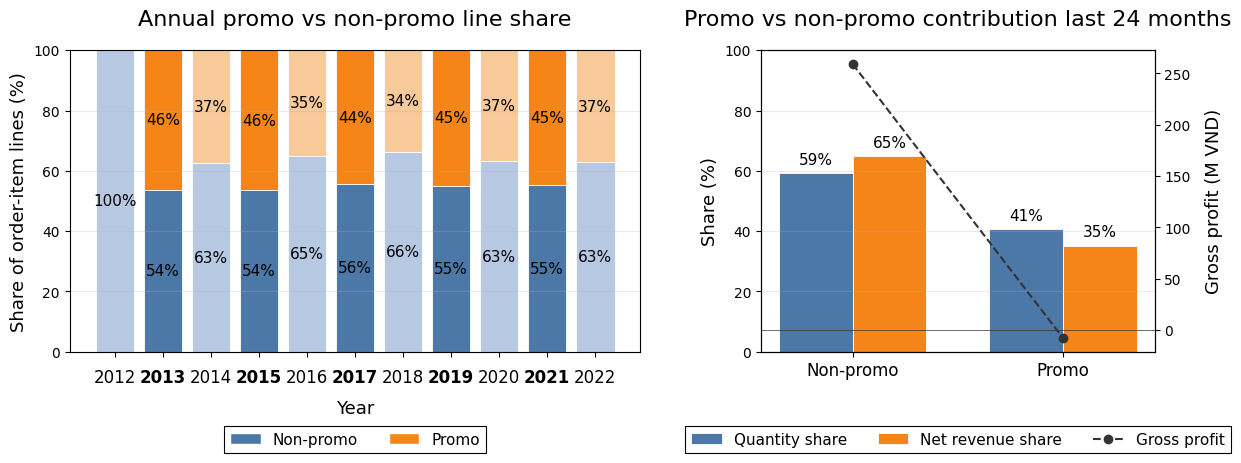

Saved: C:\Users\Admin\Downloads\Vin Datathon\EDA\promo_prevalence_last24_contribution_combined.png


In [16]:
def build_last24_promo_contribution(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()
    tmp["month"] = tmp["order_date"].dt.to_period("M").dt.to_timestamp()
    max_month = tmp["month"].max()
    cutoff = max_month - pd.DateOffset(months=23)

    last24 = tmp[tmp["month"] >= cutoff].copy()

    contrib = (
        last24.groupby("promo_flag", as_index=False)
        .agg(
            quantity=("quantity", "sum"),
            net_revenue=("net_revenue", "sum"),
            gross_profit=("gross_profit", "sum"),
        )
    )

    contrib["group"] = np.where(contrib["promo_flag"].eq(1), "Promo", "Non-promo")
    contrib["quantity_share"] = contrib["quantity"] / contrib["quantity"].sum()
    contrib["net_revenue_share"] = contrib["net_revenue"] / contrib["net_revenue"].sum()
    contrib["gross_profit_million"] = contrib["gross_profit"] / 1e6

    contrib = (
        contrib.set_index("group")
        .reindex(["Non-promo", "Promo"])
        .reset_index()
    )

    return contrib


def plot_annual_promo_and_last24_contribution(
    annual_share: pd.DataFrame,
    df: pd.DataFrame,
    *,
    output_base: Path,
) -> None:
    contribution = build_last24_promo_contribution(df)

    years = annual_share["year"].astype(str).to_numpy()
    year_nums = annual_share["year"].astype(int).to_numpy()

    nonpromo = annual_share["nonpromo_line_share"].to_numpy(dtype=float) * 100
    promo = annual_share["promo_line_share"].to_numpy(dtype=float) * 100

    # Odd years = darker shades, even years = lighter shades
    nonpromo_colors = [
        "#4C78A8" if y % 2 == 1 else "#B7C9E2"
        for y in year_nums
    ]
    promo_colors = [
        "#F58518" if y % 2 == 1 else "#F8C999"
        for y in year_nums
    ]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5.2),
        gridspec_kw={"width_ratios": [1.45, 1.0]}
    )

    # -------------------------
    # Panel A: Annual line share
    # -------------------------
    ax = axes[0]

    ax.bar(
        years,
        nonpromo,
        label="Non-promo",
        color=nonpromo_colors,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.bar(
        years,
        promo,
        bottom=nonpromo,
        label="Promo",
        color=promo_colors,
        edgecolor="white",
        linewidth=0.6,
    )

    ax.set_title("Annual promo vs non-promo line share", pad=18, fontsize=TITLE_SIZE)
    ax.set_xlabel("Year", labelpad=10, fontsize=LABEL_SIZE)
    ax.set_ylabel("Share of order-item lines (%)", fontsize=LABEL_SIZE)
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.25)

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, rotation=0)
    ax.tick_params(axis="x", pad=8, labelsize=TICK_SIZE)

    # Bold odd-year labels
    for tick in ax.get_xticklabels():
        year = int(tick.get_text())
        if year % 2 == 1:
            tick.set_fontweight("bold")

    # Percentage labels
    for i, (n_val, p_val) in enumerate(zip(nonpromo, promo)):
        if n_val >= 8:
            ax.text(
                i,
                n_val / 2,
                f"{n_val:.0f}%",
                ha="center",
                va="center",
                fontsize=ANNOT_SIZE,
            )
        if p_val >= 8:
            ax.text(
                i,
                n_val + p_val / 2,
                f"{p_val:.0f}%",
                ha="center",
                va="center",
                fontsize=ANNOT_SIZE,
            )

    legend_handles = [
        Patch(facecolor="#4C78A8", edgecolor="white", label="Non-promo"),
        Patch(facecolor="#F58518", edgecolor="white", label="Promo"),
    ]

    legend_a = ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        fontsize=LEGEND_SIZE,
    )
    legend_a.get_frame().set_linewidth(0.8)
    legend_a.get_frame().set_alpha(1.0)
    legend_a.get_frame().set_facecolor("white")

    # -------------------------
    # Panel B: Last-24m contribution
    # -------------------------
    ax = axes[1]

    x = np.arange(len(contribution))
    width = 0.35

    ax.bar(
        x - width / 2,
        contribution["quantity_share"] * 100,
        width,
        label="Quantity share",
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.6,
    )
    ax.bar(
        x + width / 2,
        contribution["net_revenue_share"] * 100,
        width,
        label="Net revenue share",
        color="#F58518",
        edgecolor="white",
        linewidth=0.6,
    )

    ax.set_title("Promo vs non-promo contribution last 24 months", pad=18, fontsize=TITLE_SIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(contribution["group"], fontsize=TICK_SIZE)
    ax.set_ylabel("Share (%)", fontsize=LABEL_SIZE)
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.25)

    for i, row in contribution.iterrows():
        ax.text(
            i - width / 2,
            row["quantity_share"] * 100 + 2,
            f'{row["quantity_share"] * 100:.0f}%',
            ha="center",
            va="bottom",
            fontsize=ANNOT_SIZE,
        )
        ax.text(
            i + width / 2,
            row["net_revenue_share"] * 100 + 2,
            f'{row["net_revenue_share"] * 100:.0f}%',
            ha="center",
            va="bottom",
            fontsize=ANNOT_SIZE,
        )

    ax2 = ax.twinx()
    ax2.plot(
        x,
        contribution["gross_profit_million"],
        marker="o",
        linestyle="--",
        color="#333333",
        label="Gross profit",
    )
    ax2.axhline(0, color="#333333", linewidth=0.5)
    ax2.set_ylabel("Gross profit (M VND)", fontsize=LABEL_SIZE, labelpad = 10)

    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    legend_b = ax.legend(
        lines_1 + lines_2,
        labels_1 + labels_2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        fontsize=LEGEND_SIZE,
    )
    legend_b.get_frame().set_linewidth(0.8)
    legend_b.get_frame().set_alpha(1.0)
    legend_b.get_frame().set_facecolor("white")

    fig.subplots_adjust(bottom=0.30, wspace=0.25)

    output_png = output_base.with_suffix(".png")
    fig.savefig(
        output_png,
        dpi=220,
        bbox_inches="tight",
        bbox_extra_artists=(legend_a, legend_b),
    )
    plt.show()

    print("Saved:", output_png)


plot_annual_promo_and_last24_contribution(
    annual_share,
    df,
    output_base=OUT_DIR / "promo_prevalence_last24_contribution_combined",
)

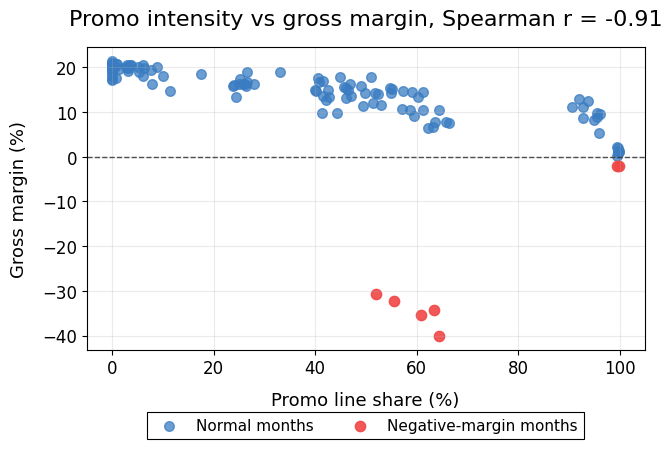

Saved: C:\Users\Admin\Downloads\Vin Datathon\EDA\promo_intensity_vs_gross_margin.png


In [18]:
def build_monthly_promo_panel(df: pd.DataFrame) -> pd.DataFrame:
    """Build monthly promotion and margin panel from item-level dataframe."""
    tmp = df.copy()
    tmp["month"] = tmp["order_date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        tmp.groupby("month", as_index=False)
        .agg(
            lines=("line_count", "sum"),
            promo_lines=("promo_lines", "sum"),
            quantity=("quantity", "sum"),
            promo_quantity=("promo_quantity", "sum"),
            net_revenue=("net_revenue", "sum"),
            promo_net_revenue=("promo_net_revenue", "sum"),
            gross_profit=("gross_profit", "sum"),
            promo_gross_profit=("promo_gross_profit", "sum"),
            discount_amount=("discount_amount", "sum"),
        )
    )

    monthly["promo_line_share"] = (
        monthly["promo_lines"] / monthly["lines"].replace(0, np.nan)
    )
    monthly["promo_quantity_share"] = (
        monthly["promo_quantity"] / monthly["quantity"].replace(0, np.nan)
    )
    monthly["promo_net_revenue_share"] = (
        monthly["promo_net_revenue"] / monthly["net_revenue"].replace(0, np.nan)
    )
    monthly["gross_margin"] = (
        monthly["gross_profit"] / monthly["net_revenue"].replace(0, np.nan)
    )
    monthly["discount_to_revenue"] = (
        monthly["discount_amount"] / monthly["net_revenue"].replace(0, np.nan)
    )

    return monthly


def plot_promo_intensity_vs_margin(
    monthly: pd.DataFrame,
    *,
    output_base: Path,
) -> None:
    """Plot promo line share vs gross margin and save PNG only."""
    corr = monthly[["promo_line_share", "gross_margin"]].corr(method="spearman").iloc[0, 1]
    margin_crash = monthly["gross_margin"] < 0

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    ax.scatter(
        monthly.loc[~margin_crash, "promo_line_share"] * 100,
        monthly.loc[~margin_crash, "gross_margin"] * 100,
        label="Normal months",
        alpha=0.75,
        color="#3A7CC2",
        s=48,
    )

    ax.scatter(
        monthly.loc[margin_crash, "promo_line_share"] * 100,
        monthly.loc[margin_crash, "gross_margin"] * 100,
        label="Negative-margin months",
        alpha=0.90,
        color="#F14646",
        s=55,
    )

    ax.axhline(
        0,
        linestyle="--",
        color="#333333",
        linewidth=1.0,
        alpha=0.85,
    )

    ax.set_title(
        f"Promo intensity vs gross margin, Spearman r = {corr:.2f}",
        pad=16,
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Promo line share (%)", labelpad=10, fontsize=LABEL_SIZE)
    ax.set_ylabel("Gross margin (%)", labelpad=10, fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.25)

    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        fontsize=LEGEND_SIZE,
    )
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_alpha(1.0)
    legend.get_frame().set_facecolor("white")

    style_axis_fonts(ax)

    fig.subplots_adjust(bottom=0.25)

    output_png = output_base.with_suffix(".png")
    fig.savefig(
        output_png,
        dpi=220,
        bbox_inches="tight",
        bbox_extra_artists=(legend,),
    )
    plt.show()

    print("Saved:", output_png)


monthly_promo_panel = build_monthly_promo_panel(df)
monthly_promo_panel.to_csv(OUT_DIR / "monthly_promo_margin_panel.csv", index=False)

plot_promo_intensity_vs_margin(
    monthly_promo_panel,
    output_base=OUT_DIR / "promo_intensity_vs_gross_margin",
)